<a href="https://colab.research.google.com/github/SergiSama/UIC-CRB1-2026-2027/blob/main/m2_vectors_transforms_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2 · Notebook 1 — Vectors & Transformations
### Computing, Robotics & Bionics · companion to A. Géron, *Hands-On Machine Learning with Scikit-Learn and PyTorch*

A **self-contained** geometric linear-algebra reference (no other notebook needed). It covers the vector
and matrix material of Géron's `math_linear_algebra`, re-ordered around **geometry** and visualised live:
the dot product and projection, matrices as maps, the transformation zoo (scaling, rotation, reflection,
shear, projection), orthonormal matrices and rigid motions, the determinant, and change of basis. The
rotations and orthonormal frames here are the same $SO(3)$ ideas as the Robotics & Bionics unit.

Run in **Google Colab** (*Runtime → Run all*). Everything is offline, except the optional bonus
image download at the end (falls back to a placeholder if you have no internet access).

**Contents**
1. The scalar product in a general basis
2. Orthonormal bases and the dot product formula
3. Length: the L2 norm
4. Geometric meaning: angle, orthogonality, cosine similarity
5. Projection
6. Gram-Schmidt orthonormalization
7. Matrices as maps (columns = images of the basis)
8. The transformation zoo (visualised)
9. Composition and non-commutativity
10. Orthogonal matrices and rigid motions
11. The determinant as area scaling, and rank
12. Change of basis

Bonus: uncovering a hidden image (Holbein's *The Ambassadors*)

Most sections end with an **Exercise**; run the **Solution** cell to check.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)
print("ready")

ready


---
## 1 · The scalar product in a general basis

Coordinates are numbers *relative to a chosen basis* `e1, e2, ...`: `v = v1*e1 + v2*e2 + ...`. The **scalar product** `<v,w>` cannot be read off those numbers alone unless you also know how the basis vectors relate to each other -- via the **Gram matrix** `G[i,j] = <e_i, e_j>`, so `<v,w> = v.T @ G @ w`. If the basis is *not* orthonormal, `G` is not the identity, and `<v,w>` is *not* simply `sum(v_i * w_i)`.


In [ ]:
# A basis that is NOT orthonormal
e1 = np.array([1.0, 0.0])
e2 = np.array([1.0, 1.0])
G = np.array([[e1 @ e1, e1 @ e2],
              [e2 @ e1, e2 @ e2]])
print("Gram matrix G:\n", G)

v_coords = np.array([2.0, 1.0])    # v = 2*e1 + 1*e2
w_coords = np.array([1.0, -1.0])   # w = 1*e1 - 1*e2

scalar_via_G = v_coords @ G @ w_coords
v_std = v_coords[0] * e1 + v_coords[1] * e2
w_std = w_coords[0] * e1 + w_coords[1] * e2
scalar_via_dot = v_std @ w_std

print("<v,w> via v.T @ G @ w                  :", scalar_via_G)
print("<v,w> via ordinary dot (standard coords):", scalar_via_dot)


Gram matrix G:
 [[1. 1.]
 [1. 2.]]
<v,w> via v.T @ G @ w                  : -1.0
<v,w> via ordinary dot (standard coords): -1.0


**Exercise 1.** Two EMG electrodes are mounted at a fixed, non-perpendicular angle, so their reading axes form a basis `f1 = np.array([1.0, 0.0])`, `f2 = np.array([0.5, 1.0])` (not orthonormal). Build the Gram matrix `G` for this basis, then for the coordinate vectors `v = (2, -1)` and `w = (1, 1)` (i.e. `v = 2*f1 - f2`, `w = f1 + f2`) compute `<v,w>` two ways: via `v.T @ G @ w`, and via the ordinary dot product after writing `v, w` out in standard coordinates. Confirm the two answers agree.

> 🤖 *Gemini tip:* "Given two non-orthogonal 2-D basis vectors in NumPy, show me how to build their Gram matrix and use it to compute the scalar product of two vectors given in that basis's coordinates, then check it against the ordinary dot product in standard coordinates."


In [ ]:
f1 = np.array([1.0, 0.0])
f2 = np.array([0.5, 1.0])

# Your code here


---
## 2 · Orthonormal bases and the dot product formula

A basis is **orthonormal** when `<e_i, e_j> = 1` if `i == j` else `0` -- exactly when `G = I`. Then `<v,w> = v.T @ w = sum(v_i * w_i)`: the familiar **dot product** is a *consequence* of orthonormality, not a definition in its own right. NumPy's arrays underline the point: a 1-D array has no row/column orientation at all, so `x.T` does nothing and `x @ y` just works -- the row-times-column bookkeeping of `x.T @ y` is a convention for literal matrices, not a property of the scalar product itself.


In [ ]:
# The standard basis is orthonormal: its Gram matrix is the identity
I2 = np.eye(2)
print("standard-basis Gram matrix:\n", I2)

x = np.array([3.0, -2.0])
y = np.array([1.0, 4.0])
print("x @ y                      :", x @ y)   # matches x.T @ I2 @ y trivially
print("x.T is a no-op on a 1-D array:", np.array_equal(x.T, x))


standard-basis Gram matrix:
 [[1. 0.]
 [0. 1.]]
x @ y                      : -5.0
x.T is a no-op on a 1-D array: True


**Exercise 2.** For `x = np.array([1.0, 2.0, 2.0])`: (a) confirm `x.T` is exactly the same array (no-op) by checking the shape and values; (b) compute the dot product two ways -- `x @ x`, and by reshaping to literal row/column matrices, `x.reshape(1, -1) @ x.reshape(-1, 1)` -- and show they agree once you pull the scalar out of the 1x1 result. Add a one-line comment on why NumPy's 1-D arrays skip the row/column bookkeeping a textbook column vector needs.

> 🤖 *Gemini tip:* "In NumPy, why does `.T` do nothing to a 1-D array, and how do I show that `x @ x` gives the same number as reshaping `x` into a row and a column matrix and multiplying those?"


In [ ]:
x = np.array([1.0, 2.0, 2.0])

# Your code here


---
## 3 · Length: the L2 norm

A vector is both an arrow in space and a list of features. Its **length** is its scalar product with itself, square-rooted, `||v|| = sqrt(<v,v>)` -- in the orthonormal/standard-basis case, the familiar L2 norm; the L1 and L-infinity norms appear in regularisation.


In [ ]:
x = np.array([3.0, 4.0])
print("L2 norm :", np.linalg.norm(x))         # 5.0
print("L1 norm :", np.linalg.norm(x, 1))      # 7.0
print("Linf    :", np.linalg.norm(x, np.inf)) # 4.0
print("unit    :", x / np.linalg.norm(x))     # length-1 version

L2 norm : 5.0
L1 norm : 7.0
Linf    : 4.0
unit    : [0.6 0.8]


**Exercise 3.** A wearable IMU on a patient's wrist records one sample of 3-axis acceleration `a = np.array([0.8, -0.3, 9.9])` (m/s^2, x/y/z). Compute its L2 norm (the total acceleration magnitude) and the unit vector giving its direction. Then compute the L1 norm and add a one-line comment on what it measures physically compared to the L2 norm.

> 🤖 *Gemini tip:* "I have a 3-D acceleration vector in NumPy — show me how to compute its magnitude (L2 norm) and a unit vector in the same direction, and explain when I'd use the L1 norm instead."

In [ ]:
a = np.array([0.8, -0.3, 9.9])

# Your code here


---
## 4 · Geometric meaning: angle, orthogonality, cosine similarity

Geometrically, `x·y = |x||y|cos(theta)`, so the dot product measures **alignment**: zero means perpendicular, and the **cosine similarity** is the standard way to compare two feature vectors (or two gene-expression profiles).


In [ ]:
def cosine(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

a = np.array([1.0, 2.0, 2.0])
b = np.array([2.0, 1.0, -2.0])
print("a . b      :", a @ b)                  # 0 -> orthogonal
print("orthogonal :", np.isclose(a @ b, 0))
# Two gene-expression-like profiles: similar vs opposite
p1 = np.array([5.0, 1.0, 0.2, 3.0])
p2 = np.array([4.5, 1.2, 0.1, 2.8])           # similar pattern
p3 = np.array([0.1, 4.0, 5.0, 0.2])           # different pattern
print("cos(p1,p2) :", round(cosine(p1, p2), 3), "(aligned)")
print("cos(p1,p3) :", round(cosine(p1, p3), 3), "(divergent)")

a . b      : 0.0
orthogonal : True
cos(p1,p2) : 0.998 (aligned)
cos(p1,p3) : 0.161 (divergent)


**Exercise 4.** Compute the angle (in degrees) between `u = [1, 0]` and `v = [1, 1]` from their cosine
similarity. *Hint:* `np.degrees(np.arccos(...))`.

> 🤖 *Gemini tip:* "Given two 2-D NumPy vectors, show me how to find the angle between them in degrees using the cosine similarity formula."

In [ ]:
u = np.array([1.0, 0.0]); v = np.array([1.0, 1.0])

# Your code here


---
## 5 · Projection

The projection of `y` onto the line through `x` is `(x·y / x·x) x`; the leftover residual is orthogonal
to `x`. This split — "along" plus "perpendicular" — is exactly what least squares does (Notebook 2).

projection: [2. 0.] | residual: [0. 3.] | residual . x = 0.0


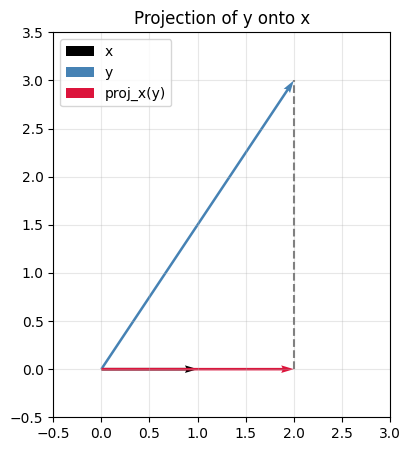

In [ ]:
def proj(y, x):
    return (x @ y) / (x @ x) * x

y = np.array([2.0, 3.0]); x = np.array([1.0, 0.0])
p = proj(y, x); r = y - p
print("projection:", p, "| residual:", r, "| residual . x =", round(r @ x, 6))

# visualise
fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(0, 0, *x, angles="xy", scale_units="xy", scale=1, color="black", label="x")
ax.quiver(0, 0, *y, angles="xy", scale_units="xy", scale=1, color="steelblue", label="y")
ax.quiver(0, 0, *p, angles="xy", scale_units="xy", scale=1, color="crimson", label="proj_x(y)")
ax.plot([p[0], y[0]], [p[1], y[1]], "--", color="gray")
ax.set_xlim(-0.5, 3); ax.set_ylim(-0.5, 3.5); ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Projection of y onto x"); plt.show()

**Exercise 5.** A physical therapist measures the raw pulling force a patient exerts, `F = np.array([4.0, 3.0])` N, while a resistance band is oriented along `d = np.array([1.0, 0.0])`. Compute the component of `F` that actually acts along the band (the projection) and the wasted perpendicular component (the residual). Report the magnitude of each.

> 🤖 *Gemini tip:* "Given a 2-D force vector and a direction vector in NumPy, show me how to split the force into the part along that direction and the part perpendicular to it, using the projection formula."

In [ ]:
F = np.array([4.0, 3.0])
d = np.array([1.0, 0.0])

# Your code here


---
## 6 · Gram-Schmidt orthonormalization

Given linearly independent vectors, Gram-Schmidt builds an **orthonormal basis** spanning the same subspace: take each vector in turn, subtract its projection onto every previous (already-orthonormal) direction — exactly the projection of Section 5, repeated — then normalise to unit length. Orthonormal bases are the backbone of QR decomposition, stable least squares, and PCA (Notebook 2); here we use one to make sense of a set of correlated biosignal channels.

In [ ]:
def gsBasis(A):
    """Classical Gram-Schmidt: build an orthonormal basis for the columns of A."""
    B = np.array(A, dtype=float)
    for i in range(B.shape[1]):
        for j in range(i):
            B[:, i] = B[:, i] - (B[:, i] @ B[:, j]) * B[:, j]   # subtract projection onto q_j
        norm = np.linalg.norm(B[:, i])
        B[:, i] = B[:, i] / norm if norm > 1e-12 else np.zeros_like(B[:, i])
    return B

# Four correlated 'lead' vectors from a toy multi-channel biosignal recording
V = np.array([
    [1.0,  0.0, 2.0, 6.0],
    [0.0,  1.0, 8.0, 2.0],
    [2.0,  8.0, 3.0, 1.0],
    [1.0, -6.0, 2.0, 3.0],
])
Q = gsBasis(V)
print("Q.T @ Q = I ?", np.allclose(Q.T @ Q, np.eye(4)))
print(Q.round(3))

Q.T @ Q = I ? True
[[ 0.408 -0.181  0.05   0.893]
 [ 0.     0.109  0.993 -0.033]
 [ 0.816  0.508 -0.065 -0.266]
 [ 0.408 -0.835  0.079 -0.361]]


A recording channel that is really a duplicate of two others (a wiring fault, or a redundant lead) shows up as a **zero column** after Gram-Schmidt — a numerical way to detect it and read off the true (lower) dimensionality of the signal.

In [ ]:
# Channel 3 here is really channel 1 - 3*channel 2 (a duplicated/redundant lead)
C = np.array([
    [1.0, 0.0,  2.0],
    [0.0, 1.0, -3.0],
    [1.0, 0.0,  2.0],
])
Qc = gsBasis(C)
print(Qc.round(3))
true_rank = int(np.sum(np.linalg.norm(Qc, axis=0) > 1e-8))
print("effective (numeric) rank of the 3 channels:", true_rank)

[[0.707 0.    0.   ]
 [0.    1.    0.   ]
 [0.707 0.    0.   ]]
effective (numeric) rank of the 3 channels: 2


**Exercise 6.** `gsBasis` above uses a nested loop (`for i ... for j < i`). Write a **vectorized** version `gsBasisV(A)` that, for each column `i`, subtracts the projection onto *all* previous orthonormal columns in one shot — `B[:, :i] @ (B[:, :i].T @ B[:, i])` — instead of looping over `j`. Confirm it agrees with `gsBasis` on `V` above, then compare the two on a random `400 x 300` matrix with `%timeit`.

> 🤖 *Gemini tip:* "I have a Gram-Schmidt orthonormalization function that loops over previous columns one at a time to subtract projections — help me vectorize the inner loop into a single matrix projection, and show me how to benchmark both versions with %timeit."

In [ ]:
rng = np.random.default_rng(0)
big = rng.random((400, 300))

# Your code here


With an orthonormal basis in hand, projecting onto the subspace it spans is just a couple of dot products: express the vector in that basis, drop the coordinates you don't want, map back. This is the general recipe behind every projection/reflection/rotation in the rest of this notebook, now applied to an arbitrary (not axis-aligned) subspace.

In [ ]:
# Project a new noisy reading onto the 2-D subspace spanned by the first two lead directions
reading = np.array([3.0, -1.0, 4.0, 0.5])
Qsub = Q[:, :2]                      # orthonormal basis of the target subspace
coeffs = Qsub.T @ reading            # coordinates in that subspace (Qsub is orthonormal)
projected = Qsub @ coeffs            # back to the original 4-D space
residual = reading - projected
print("coordinates in the 2 template directions:", coeffs.round(3))
print("projected reading:", projected.round(3))
print("residual orthogonal to the subspace ?", np.allclose(Qsub.T @ residual, 0))

coordinates in the 2 template directions: [4.695 0.962]
projected reading: [1.742 0.105 4.322 1.114]
residual orthogonal to the subspace ? True


---
## 7 · Matrices as maps (columns = images of the basis)

Read a matrix as a **verb**. The columns of `A` are where it sends the standard basis vectors `e1, e2`,
so `A @ x` is a weighted sum of the columns. We will *see* this throughout the zoo below.

In [ ]:
A = np.array([[2.0, 1.0],
              [0.0, 3.0]])
e1, e2 = np.array([1.0, 0.0]), np.array([0.0, 1.0])
print("A @ e1 =", A @ e1, "= first column ", A[:, 0])
print("A @ e2 =", A @ e2, "= second column", A[:, 1])

A @ e1 = [2. 0.] = first column  [2. 0.]
A @ e2 = [1. 3.] = second column [1. 3.]


**Exercise 7.** Mechanical crosstalk between the two axes of a low-cost accelerometer can be modelled as a matrix `A = np.array([[1.10, 0.05], [0.02, 0.95]])` acting on the true signal. Find where it sends `e1` and `e2` (its columns), then apply it to a true reading `x = np.array([2.0, -1.0])` to see the (slightly corrupted) sensor output `A @ x`.

> 🤖 *Gemini tip:* "Explain what the columns of a 2x2 NumPy matrix tell me about where it sends the standard basis vectors, then show me how to apply the matrix to an arbitrary vector."

In [ ]:
Across = np.array([[1.10, 0.05], [0.02, 0.95]])
x_true = np.array([2.0, -1.0])

# Your code here


---
## 8 · The transformation zoo (visualised)

We apply each canonical 2-D map to a small asymmetric shape (so rotations and reflections are obvious)
and to the basis vectors. The shape stands in for a configuration of anatomical landmarks — exactly the
kind of object you rotate/reflect when **registering** medical images or aligning a robot frame.

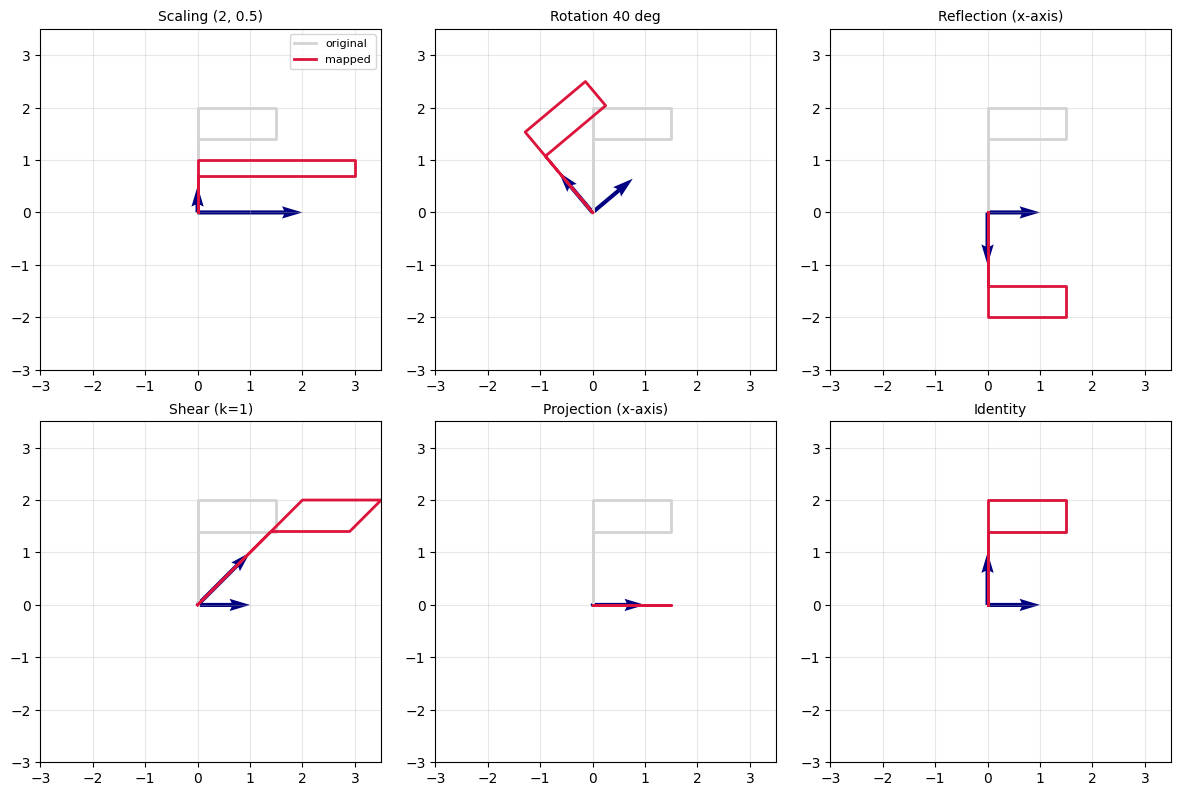

In [ ]:
# An asymmetric 'flag' shape as a set of 2-D points (columns are points)
shape = np.array([
    [0, 0, 1.5, 1.5, 0.0, 0.0],   # x
    [0, 2, 2.0, 1.4, 1.4, 0.0],   # y
])

def plot_map(A, title, ax):
    new = A @ shape
    ax.plot(*np.c_[shape, shape[:, :1]], color="lightgray", lw=2, label="original")
    ax.plot(*np.c_[new,   new[:, :1]],   color="crimson",  lw=2, label="mapped")
    # basis vectors and their images
    for v, c in [(np.array([1,0]), "black"), (np.array([0,1]), "black")]:
        ax.quiver(0,0,*(A@v), angles="xy", scale_units="xy", scale=1, color="navy", width=0.012)
    ax.set_title(title, fontsize=10); ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_xlim(-3, 3.5); ax.set_ylim(-3, 3.5)

theta = np.radians(40)
maps = {
    "Scaling (2, 0.5)":    np.array([[2,0],[0,0.5]]),
    "Rotation 40 deg":     np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]]),
    "Reflection (x-axis)": np.array([[1,0],[0,-1]]),
    "Shear (k=1)":         np.array([[1,1],[0,1]]),
    "Projection (x-axis)": np.array([[1,0],[0,0]]),
    "Identity":            np.eye(2),
}
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (name, M) in zip(axes.ravel(), maps.items()):
    plot_map(M, name, ax)
axes[0,0].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Exercise 8.** Build the matrix that rotates by 90 degrees, apply it to `shape`, and confirm a point
that was at `(1.5, 0)` lands at `(0, 1.5)`.

> 🤖 *Gemini tip:* "Show me how to build a 2-D rotation matrix for a specific angle in NumPy and apply it to a set of points."

In [ ]:
# Your code here


---
## 9 · Composition and non-commutativity

Multiplying matrices **composes** maps, applied right-to-left, and order matters: rotate-then-reflect is
not reflect-then-rotate.

In [ ]:
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
F = np.array([[1.0, 0.0], [0.0, -1.0]])     # reflect in x-axis
print("R @ F =\n", R @ F)
print("F @ R =\n", F @ R)
print("equal?", np.allclose(R @ F, F @ R))  # False -> order matters

R @ F =
 [[ 0.766  0.643]
 [ 0.643 -0.766]]
F @ R =
 [[ 0.766 -0.643]
 [-0.643 -0.766]]
equal? False


**Exercise 9.** Registering two medical images sometimes requires a rotation *and* a reflection (e.g. one scan was mirrored during acquisition). Build a 30-degree rotation matrix `R30` and reuse the horizontal-reflection matrix `F` from above, then apply *rotate-then-reflect* and *reflect-then-rotate* to the anatomical landmark point `p = np.array([2.0, 1.0])`. Confirm the two pipelines give different results.

> 🤖 *Gemini tip:* "I have two 2x2 NumPy transformation matrices; show me how to apply them to a point in two different orders and confirm matrix multiplication doesn't commute."

In [ ]:
p = np.array([2.0, 1.0])

# Your code here


---
## 10 · Orthogonal matrices and rigid motions

An **orthogonal** matrix satisfies `Q.T @ Q = I` (so its inverse is its transpose). It preserves lengths
and angles — a rigid motion. `det(Q) = +1` is a **rotation**, `det(Q) = -1` a **reflection**. This is the
$SO(3)$ structure used to orient a robot or a surgical tool.

In [ ]:
Q = R                          # a rotation
print("Q.T @ Q = I ?", np.allclose(Q.T @ Q, np.eye(2)))
print("Q^-1 == Q.T ?", np.allclose(np.linalg.inv(Q), Q.T))
print("det(rotation)  =", round(np.linalg.det(Q), 3))    # +1
print("det(reflection)=", round(np.linalg.det(F), 3))    # -1
# length preservation
w = np.array([3.0, 4.0])
print("|w| =", np.linalg.norm(w), "| |Qw| =", round(np.linalg.norm(Q @ w), 3))

Q.T @ Q = I ? True
Q^-1 == Q.T ? True
det(rotation)  = 1.0
det(reflection)= -1.0
|w| = 5.0 | |Qw| = 5.0


**Exercise 10.** A colleague claims a candidate calibration matrix `C = np.array([[0.8, 0.6], [0.6, -0.8]])` represents a valid rigid rotation of a surgical tool's reference frame. Check whether `C` is orthogonal (`C.T @ C == I`) and compute `det(C)`. Is it a rotation, a reflection, or neither?

> 🤖 *Gemini tip:* "Given a 2x2 NumPy matrix, show me how to test whether it's orthogonal and how the sign of its determinant tells me if it's a rotation or a reflection."

In [ ]:
C = np.array([[0.8, 0.6], [0.6, -0.8]])

# Your code here


---
## 11 · The determinant as area scaling, and rank

`det(A)` is the factor by which the map scales area (with sign = orientation). A zero determinant means
the map collapses the plane onto a line — it is singular and cannot be inverted.

The **rank** is the dimension of the output space — how many independent directions survive the map.
A full-rank map is invertible; a rank-deficient one (like a projection) has collapsed at least one
direction, destroying information that cannot be recovered — in data terms, rank-deficient columns
(features) are redundant, which is exactly what dimensionality reduction exploits.

In [ ]:
for name, M in [("scaling(2,0.5)", np.array([[2,0],[0,0.5]])),
                ("rotation",       R),
                ("shear(k=1)",     np.array([[1,1],[0,1]])),
                ("projection",     np.array([[1,0],[0,0]]))]:
    print(f"{name:16s} det = {np.linalg.det(M): .3f}  | rank = {np.linalg.matrix_rank(M)}")
print("\nUnit square has area 1; after scaling(2,0.5) it has area", abs(np.linalg.det(np.array([[2,0],[0,0.5]]))))
print("Note: projection has det = 0 and rank 1 -- it collapses the plane onto a line, so it cannot be inverted.")

scaling(2,0.5)   det =  1.000  | rank = 2
rotation         det =  1.000  | rank = 2
shear(k=1)       det =  1.000  | rank = 2
projection       det =  0.000  | rank = 1

Unit square has area 1; after scaling(2,0.5) it has area 1.0
Note: projection has det = 0 and rank 1 -- it collapses the plane onto a line, so it cannot be inverted.


**Exercise 11.** A microscope's pixel grid is not perfectly square: converting pixel coordinates to physical (µm) coordinates uses the anisotropic scaling matrix `A = np.array([[1.2, 0.0], [0.0, 0.8]])`. Compute `det(A)` and use it to convert a measured cell area of `150` pixels^2 into µm^2.

> 🤖 *Gemini tip:* "Explain how the determinant of a 2x2 scaling matrix relates to how areas change under that transformation, and show me how to use it to convert a pixel area into physical units."

In [ ]:
Apix = np.array([[1.2, 0.0], [0.0, 0.8]])
area_px = 150

# Your code here


**Exercise 11b — Rank.** A resting-state fMRI connectivity map that has collapsed onto a single dominant
mode can be modelled by the rank-deficient matrix `Mp = np.array([[1, 0], [0, 0]])` (all signal projected
onto one axis). Compute `np.linalg.matrix_rank(Mp)` and `np.linalg.det(Mp)`, and in one comment explain what
a rank-1, determinant-0 matrix means for trying to invert it — i.e. recover the discarded second axis from
the output alone.

> 🤖 *Gemini tip:* "Given a 2x2 NumPy matrix, show me how to compute its rank and determinant, and explain in plain terms what it means when a matrix is rank-deficient with determinant zero."


In [ ]:
Mp = np.array([[1, 0], [0, 0]])   # rank-1 projection onto the x-axis

# Your code here


---
## 12 · Change of basis

A point's coordinates depend on the basis. If `P` holds new basis vectors as columns, then
`x = P @ x'` and `x' = inv(P) @ x`. A map becomes `A' = inv(P) @ A @ P` in the new basis (a *similarity
transform*) — the idea PCA uses to find axes in which data is simplest.

In [ ]:
# New orthonormal basis: rotated axes
P = R                                  # columns are the new basis vectors
x_std = np.array([1.0, 1.0])           # a point in standard coordinates
x_new = np.linalg.inv(P) @ x_std       # its coordinates in the rotated basis
print("standard coords:", x_std)
print("rotated-basis coords:", x_new)
print("back to standard:", P @ x_new)  # recovers x_std
# a map in the new basis (similarity transform)
A = np.array([[2.0, 0.0], [0.0, 0.5]])
print("A in rotated basis:\n", np.linalg.inv(P) @ A @ P)

standard coords: [1. 1.]
rotated-basis coords: [1.409 0.123]
back to standard: [1. 1.]
A in rotated basis:
 [[ 1.38  -0.739]
 [-0.739  1.12 ]]


**Exercise 12.** Take the basis `P = [[1,1],[0,1]]` (a sheared basis). Find the coordinates of the
standard point `(2, 3)` in this basis, then map back to confirm.

> 🤖 *Gemini tip:* "Explain how to find a point's coordinates in a non-standard basis using matrix inversion, and how to map them back to standard coordinates."

In [ ]:
P2 = np.array([[1.0, 1.0], [0.0, 1.0]])

# Your code here


---
## Bonus · Uncovering a hidden image (Holbein's *The Ambassadors*)

Hans Holbein the Younger hid an anamorphic skull in his 1533 painting *The Ambassadors*: distorted by a scaling and a shear so it only resolves into a normal image from an extreme viewing angle — or, here, once we invert the transformation. This is exactly the composition-and-inverse machinery from Sections 9–10 above, applied to a real image: the same recipe you'll use in Module 4 to rectify a tilted scan or a skewed microscope/endoscopy frame.

He applied a vertical squash

$$
HS_1 = \begin{bmatrix} 1 & 0 \\ 0 & 1/8 \end{bmatrix}
$$

then a shear

$$
HS_2 = \begin{bmatrix} 1 & 0 \\ 1/2 & 1 \end{bmatrix}
$$

To undo it we need the inverse of the composition $(HS_2\,HS_1)^{-1}$ — remembering that image coordinates have $y$ pointing *down*, so a $y$-axis flip has to bracket the transform, the same trick as the reflections in Section 10.

could not download the painting here (this cell needs internet -- it works in Colab): <urlopen error Tunnel connection failed: 403 Forbidden>


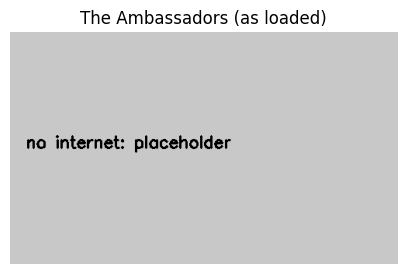

In [ ]:
import cv2
import urllib.request

def load_image(url):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    resp = urllib.request.urlopen(req, timeout=20)
    data = np.asarray(bytearray(resp.read()), dtype="uint8")
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError("Failed to decode image.")
    return img

url = ("https://upload.wikimedia.org/wikipedia/commons/thumb/8/88/"
       "Hans_Holbein_the_Younger_-_The_Ambassadors_-_Google_Art_Project.jpg/"
       "500px-Hans_Holbein_the_Younger_-_The_Ambassadors_-_Google_Art_Project.jpg")
try:
    Ambassadors = load_image(url)
    print("loaded painting, shape:", Ambassadors.shape)
except Exception as e:
    print("could not download the painting here (this cell needs internet -- it works in Colab):", e)
    Ambassadors = np.full((300, 500, 3), 200, dtype=np.uint8)   # placeholder so the notebook still runs
    cv2.putText(Ambassadors, "no internet: placeholder", (20, 150),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

plt.figure(figsize=(5, 5)); plt.imshow(cv2.cvtColor(Ambassadors, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.title("The Ambassadors (as loaded)"); plt.show()

**Bonus Exercise.** Build the matrix that undoes Holbein's distortion: compose his scaling `HS1` and shear `HS2` in the order he applied them, then invert the composition (remember the `y`-axis flip). Apply the result as an affine warp (`cv2.warpAffine`) to `Ambassadors` and see whether the hidden image resolves.

> 🤖 *Gemini tip:* "I have two 2x2 NumPy matrices representing a scale and a shear that were applied to an image, and I want to build the inverse transform that undoes both, then apply it with cv2.warpAffine. Walk me through composing the matrices, inverting, handling the image y-axis flip, and computing the output canvas size from the transformed corners."

In [ ]:
# Your code here


---
### You now have the geometry
Vectors and the dot product, projection, Gram-Schmidt orthonormalization, matrices as maps, the
transformation zoo, orthonormal/rigid motions, the determinant, and change of basis -- plus a
bonus look at Holbein's hidden anamorphosis. **Next:** Notebook 2 turns these into the
eigendecomposition and SVD, then least squares and PCA on real biomedical data.